# 06 – Final Comparison: All Three Models
Unified evaluation table and visualisations for the project report.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
from src.evaluation.compare import build_comparison
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Summary table

In [2]:
rows = build_comparison(Path('..'))
df = pd.DataFrame(rows).set_index('model')
summary = df[['precision', 'recall', 'f1', 'latency_ms']].copy()
summary.columns = ['Precision', 'Recall', 'F1', 'Latency (ms)']
display(summary.style.highlight_max(axis=0, subset=['Precision','Recall','F1'],
                                    props='background-color: #d4f1c4; font-weight: bold'))

,Precision,Recall,F1,Latency (ms)
model,,,,
Presidio (REGEX),0.492300,0.368000,0.421100,14.305000
DeBERTa-v3 (NER),0.989500,0.991000,0.990300,-
Gemini 1.5 Flash (LLM),0.206300,0.154100,0.176400,2195.812000


## 2. Overall P / R / F1 bar chart

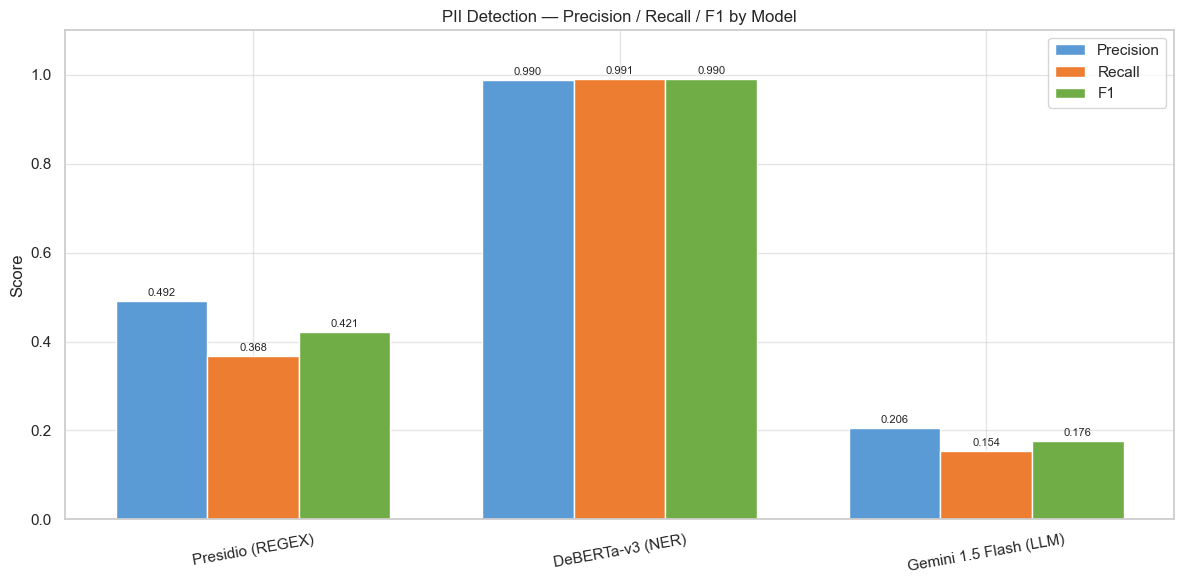

In [3]:
models = df.index.tolist()
x = np.arange(len(models))
width = 0.25
colors = ['#5b9bd5', '#ed7d31', '#70ad47']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (metric, color) in enumerate(zip(['precision', 'recall', 'f1'], colors)):
    vals = df[metric].tolist()
    bars = ax.bar(x + i*width, vals, width, label=metric.capitalize(), color=color, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(models, rotation=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('PII Detection — Precision / Recall / F1 by Model')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/results/comparison_prf.png', dpi=150)
plt.show()

## 3. Per-entity F1 heatmap

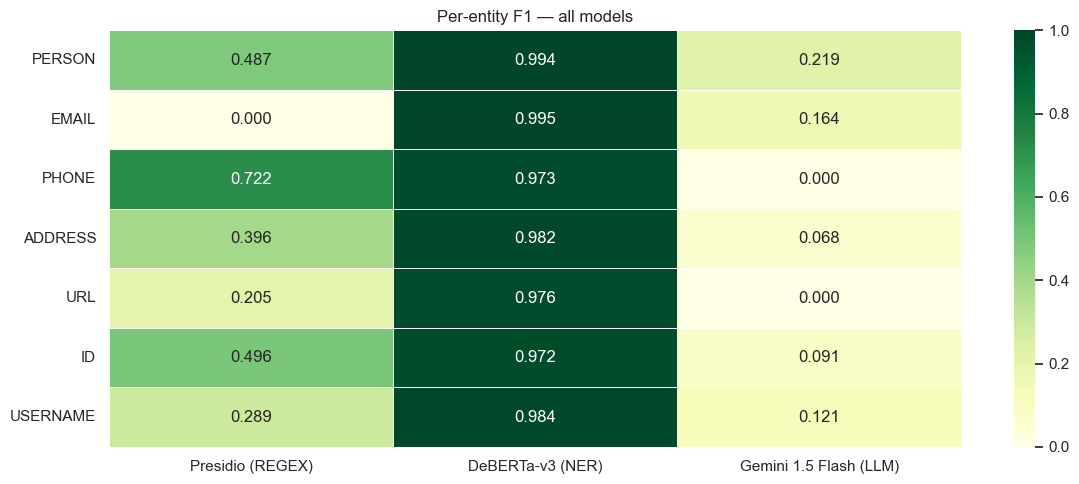

In [4]:
entity_types = ['PERSON', 'EMAIL', 'PHONE', 'ADDRESS', 'URL', 'ID', 'USERNAME']
heat_data = pd.DataFrame(
    {row['model']: [row.get(f'{e}_f1', 0) for e in entity_types] for row in rows},
    index=entity_types
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='YlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Per-entity F1 — all models')
plt.tight_layout()
plt.savefig('../outputs/results/comparison_heatmap.png', dpi=150)
plt.show()

## 4. Latency comparison

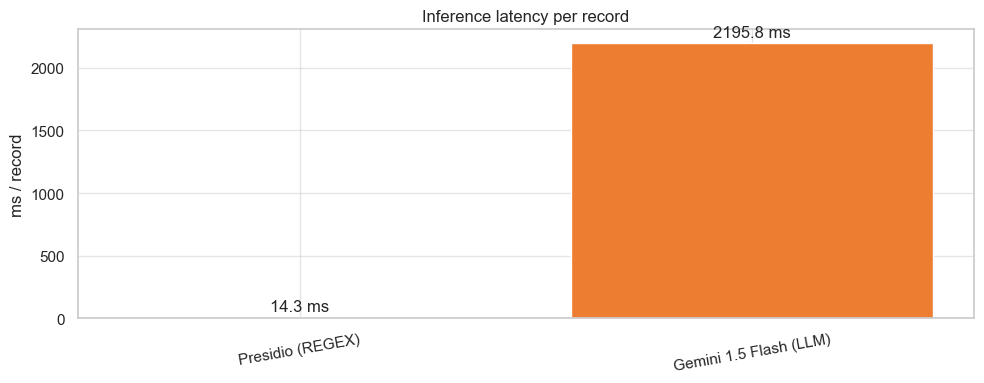

In [5]:
lat_vals = [r['latency_ms'] for r in rows if isinstance(r.get('latency_ms'), (int, float))]
lat_models = [r['model'] for r in rows if isinstance(r.get('latency_ms'), (int, float))]

if lat_vals:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(lat_models, lat_vals, color=['#5b9bd5', '#ed7d31', '#70ad47'][:len(lat_vals)], edgecolor='white')
    ax.bar_label(bars, fmt='%.1f ms', padding=2)
    ax.set_ylabel('ms / record')
    ax.set_title('Inference latency per record')
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.savefig('../outputs/results/comparison_latency.png', dpi=150)
    plt.show()

## 5. Cost–accuracy trade-off summary

In [6]:
cost_table = pd.DataFrame([
    {'Model': 'Presidio (REGEX)',       'GPU Cost': '$0',       'API Cost': '$0',          'Training Cost': '$0'},
    {'Model': 'DeBERTa-v3 (NER)',       'GPU Cost': '~$5-$20',  'API Cost': '$0',          'Training Cost': '~$5-$20 cloud GPU'},
    {'Model': 'Gemini 1.5 Flash (LLM)', 'GPU Cost': '$0',       'API Cost': '~$0.05-$0.20','Training Cost': '$0'},
]).set_index('Model')

display(cost_table)
print('\nNote: LLM API cost is for 500-record evaluation at ~200 tokens/record average.')

,GPU Cost,API Cost,Training Cost
Model,,,
Presidio (REGEX),$0,$0,$0
DeBERTa-v3 (NER),~$5-$20,$0,~$5-$20 cloud GPU
Gemini 1.5 Flash (LLM),$0,~$0.05-$0.20,$0



Note: LLM API cost is for 500-record evaluation at ~200 tokens/record average.
